# 02: Classifier Training and Confusion Matrix Generation

**Thesis:** *Impact of Machine-Learning Traffic Classification Errors on Multi-Class Capacity Dimensioning in Multirate Loss Systems*

This notebook trains XGBoost and MLP classifiers on the cleaned ISCX VPN-nonVPN 5-class dataset,
generates confusion matrices under clean and degraded conditions, builds synthetic CM generators,
and previews the composition impact on Kaufman-Roberts blocking probabilities.

**Inputs:**
- `data/processed/iscx_5class_15s_clean.csv` (from notebook 01)
- `data/Scenario A2-ARFF/TimeBasedFeatures-Dataset-15s-VPN.arff` (VPN domain shift)
- `src/analytical/published_cms.py` (FlowPic published CMs)
- `src/analytical/kaufman_roberts.py` (K-R recursion and composition)

**Outputs:**
- `data/processed/confusion_matrices.npz` (all empirical + synthetic CMs)

> The distributed `confusion_matrices.npz` was written by this protocol: the reduced-feature
> slots by `scripts/iscx/iscx_reduced_feature_ranking.py` (feature ranking inside each fold) and
> the MLP slots by `scripts/iscx/retrain_mlp_weighted.py` (class-balanced oversampling on each
> training fold); the cells below implement the same steps. The save cells are gated by
> `NB02_FORCE_OVERWRITE=1` so a re-run cannot overwrite that archive by accident.

> Execution record of `02_classifiers.ipynb` with its outputs. Re-run the source notebook
> from `notebooks/`, not this file. Gradient-boosted trees on the GPU are not bitwise
> reproducible across runs, so the XGBoost matrices printed here differ from
> the archive by a few points on the clean conditions and by more on the small VPN test
> partition. The MLP and published matrices reproduce exactly. The thesis quotes the archive.

## 1. Setup and Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from imblearn.over_sampling import RandomOverSampler

%matplotlib inline
sns.set_style('whitegrid')

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Add parent directory to sys.path for src imports
ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Paths
DATA_DIR = Path('..') / 'data'
PROCESSED_DIR = DATA_DIR / 'processed'
VPN_ARFF = DATA_DIR / 'Scenario A2-ARFF' / 'TimeBasedFeatures-Dataset-15s-VPN.arff'

# Class configuration (alphabetical order, used throughout)
CLASS_ORDER = ['Browsing', 'Chat', 'FileTransfer', 'Streaming', 'VoIP']
CLASS_COLORS = dict(zip(CLASS_ORDER, sns.color_palette('Set2', 5)))
N_CLASSES = len(CLASS_ORDER)

# Bandwidth demands t_k in allocation units (alphabetical class order)
T_K = np.array([2, 1, 8, 15, 1])

# 23 features used in the thesis
FEATURE_COLS = [
    'duration', 'total_fiat', 'total_biat', 'min_fiat', 'min_biat',
    'max_fiat', 'max_biat', 'mean_fiat', 'mean_biat',
    'flowPktsPerSecond', 'flowBytesPerSecond',
    'min_flowiat', 'max_flowiat', 'mean_flowiat', 'std_flowiat',
    'min_active', 'mean_active', 'max_active', 'std_active',
    'min_idle', 'mean_idle', 'max_idle', 'std_idle'
]

print(f'Classes: {CLASS_ORDER}')
print(f'Demands t_k: {T_K}')
print(f'Features: {len(FEATURE_COLS)}')
print('Setup complete.')

Classes: ['Browsing', 'Chat', 'FileTransfer', 'Streaming', 'VoIP']
Demands t_k: [ 2  1  8 15  1]
Features: 23
Setup complete.


In [2]:
# Load cleaned data from notebook 01
df = pd.read_csv(PROCESSED_DIR / 'iscx_5class_15s_clean.csv')

# Separate features and labels
X = df[FEATURE_COLS].values.astype(np.float64)
y_raw = df['class1'].values

# Encode labels with LabelEncoder (alphabetical order guaranteed)
le = LabelEncoder()
le.fit(CLASS_ORDER)
y = le.transform(y_raw)

print(f'Data shape: X={X.shape}, y={y.shape}')
print(f'Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}')
print()

# Class distribution
dist = pd.Series(y_raw).value_counts().reindex(CLASS_ORDER)
dist_pct = (dist / dist.sum() * 100).round(1)
print('Class distribution:')
for cls in CLASS_ORDER:
    print(f'  {cls:15s}: {dist[cls]:5d} ({dist_pct[cls]:5.1f}%)')
print(f'  {"Total":15s}: {dist.sum():5d}')

Data shape: X=(16090, 23), y=(16090,)
Label encoding: {np.str_('Browsing'): np.int64(0), np.str_('Chat'): np.int64(1), np.str_('FileTransfer'): np.int64(2), np.str_('Streaming'): np.int64(3), np.str_('VoIP'): np.int64(4)}

Class distribution:
  Browsing       :  5000 ( 31.1%)
  Chat           :  2086 ( 13.0%)
  FileTransfer   :  2950 ( 18.3%)
  Streaming      :   957 (  5.9%)
  VoIP           :  5097 ( 31.7%)
  Total          : 16090


## 2. Cross-Validation Framework

A reusable 5-fold stratified cross-validation harness that collects per-fold confusion matrices
(raw counts), averages them, and computes row-stochastic (recall-normalized) versions.
The averaged CM represents the expected classification error profile fed into the composition.

In [3]:
def normalize_cm(cm_raw):
    """Convert raw-count CM to row-stochastic: C_ij = P(predict j | true i)."""
    row_sums = cm_raw.sum(axis=1, keepdims=True)
    # Avoid division by zero for classes with no samples
    row_sums = np.where(row_sums == 0, 1, row_sums)
    return cm_raw.astype(np.float64) / row_sums

def train_evaluate_cv(model_fn, X, y, n_splits=5, use_sample_weight=False,
                      use_random_oversampler=False):
    """Train and evaluate a classifier using stratified k-fold cross-validation.

    With use_random_oversampler, RandomOverSampler is applied to the (scaled) training fold before fit(). For classifiers that do not expose sample_weight (e.g. MLPClassifier), this delivers a class-balanced gradient signal equivalent to weighted loss up to minibatch sampling noise.

    Returns:
    dict with keys:
        'cms_raw'      : list of per-fold raw-count CMs
        'cm_avg_raw'   : averaged raw-count CM across folds
        'cm_avg_norm'  : row-stochastic averaged CM
        'accuracies'   : per-fold accuracy scores
        'reports'      : per-fold classification report dicts
        'y_true_all'   : concatenated true labels across folds
        'y_pred_all'   : concatenated predicted labels across folds
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    scaler = StandardScaler()

    cms_raw = []
    accuracies = []
    reports = []
    y_true_all = []
    y_pred_all = []

    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Fit scaler on training fold only
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)

        # Optional class-balanced oversampling on the training fold
        if use_random_oversampler:
            ros = RandomOverSampler(random_state=RANDOM_STATE + fold_idx)
            X_train_fit, y_train_fit = ros.fit_resample(X_train_s, y_train)
        else:
            X_train_fit, y_train_fit = X_train_s, y_train

        # Train model
        model = model_fn()
        if use_sample_weight:
            sw = compute_sample_weight('balanced', y_train_fit)
            model.fit(X_train_fit, y_train_fit, sample_weight=sw)
        else:
            model.fit(X_train_fit, y_train_fit)

        # Predict
        y_pred = model.predict(X_test_s)

        # Collect metrics
        cm = confusion_matrix(y_test, y_pred, labels=np.arange(N_CLASSES))
        cms_raw.append(cm)
        accuracies.append(accuracy_score(y_test, y_pred))
        reports.append(classification_report(y_test, y_pred, output_dict=True,
                                             zero_division=0))
        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

    # Average CM across folds
    cm_avg_raw = np.mean(cms_raw, axis=0)
    cm_avg_norm = normalize_cm(cm_avg_raw)

    return {
        'cms_raw': cms_raw,
        'cm_avg_raw': cm_avg_raw,
        'cm_avg_norm': cm_avg_norm,
        'accuracies': accuracies,
        'reports': reports,
        'y_true_all': np.array(y_true_all),
        'y_pred_all': np.array(y_pred_all),
    }

def plot_cm_heatmap(cm_norm, title, ax=None, fmt='.1%', cmap='Blues'):
    """Plot a row-stochastic CM as a percentage heatmap."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))

    # Convert to percentages for display
    cm_pct = cm_norm * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap=cmap,
                xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER,
                ax=ax, vmin=0, vmax=100, linewidths=0.5,
                cbar_kws={'label': 'Percentage (%)'})
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title)

def print_cv_summary(results, name):
    """Print a summary of cross-validation results."""
    accs = results['accuracies']
    cm = results['cm_avg_norm']
    print(f'=== {name} ===')
    print(f'Per-fold accuracy: {[f"{a:.4f}" for a in accs]}')
    print(f'Mean accuracy:     {np.mean(accs):.4f} +/- {np.std(accs):.4f}')
    print()

    # Per-class recall from averaged normalized CM
    print('Per-class recall (from averaged CM):')
    for i, cls in enumerate(CLASS_ORDER):
        print(f'  {cls:15s}: {cm[i, i]:.1%}')
    print()

    # Overall classification report from concatenated predictions
    print(classification_report(
        results['y_true_all'], results['y_pred_all'],
        target_names=CLASS_ORDER, digits=4, zero_division=0
    ))

print('Cross-validation framework defined.')

Cross-validation framework defined.


## 3. XGBoost Classifier

Gradient-boosted decision trees with balanced sample weights to handle class imbalance.
XGBoost is the primary classifier for the thesis because of its strong performance on
tabular flow-level features and built-in feature importance ranking.

In [4]:
def make_xgb():
    return XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, eval_metric='mlogloss',
        device='cuda', random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
    )

xgb_results = train_evaluate_cv(make_xgb, X, y, n_splits=5, use_sample_weight=True)
print_cv_summary(xgb_results, 'XGBoost (5-fold CV, balanced weights, GPU)')

=== XGBoost (5-fold CV, balanced weights, GPU) ===
Per-fold accuracy: ['0.9186', '0.9245', '0.9242', '0.9301', '0.9236']
Mean accuracy:     0.9242 +/- 0.0037

Per-class recall (from averaged CM):
  Browsing       : 93.9%
  Chat           : 81.9%
  FileTransfer   : 88.1%
  Streaming      : 87.4%
  VoIP           : 98.8%

              precision    recall  f1-score   support

    Browsing     0.9323    0.9388    0.9355      5000
        Chat     0.8164    0.8188    0.8176      2086
FileTransfer     0.8750    0.8807    0.8779      2950
   Streaming     0.8782    0.8736    0.8759       957
        VoIP     0.9984    0.9876    0.9930      5097

    accuracy                         0.9242     16090
   macro avg     0.9001    0.8999    0.9000     16090
weighted avg     0.9245    0.9242    0.9243     16090



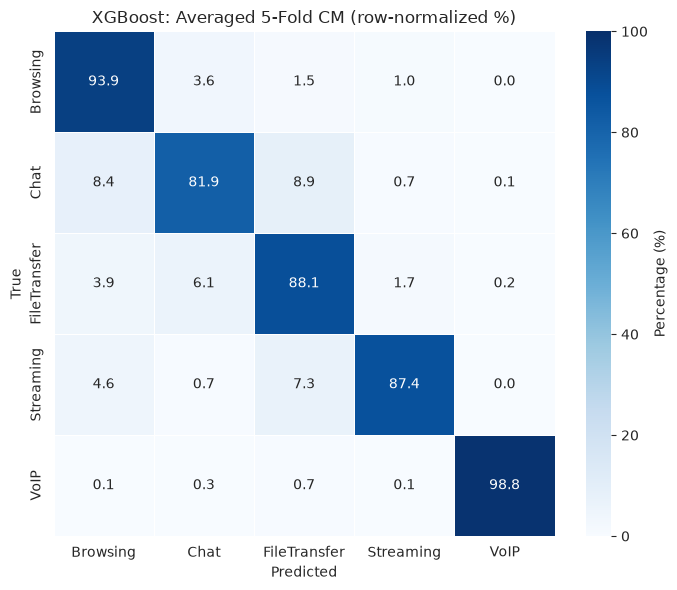

In [5]:
# Averaged confusion matrix heatmap
fig, ax = plt.subplots(figsize=(7, 6))
plot_cm_heatmap(xgb_results['cm_avg_norm'], 'XGBoost: Averaged 5-Fold CM (row-normalized %)', ax=ax)
plt.tight_layout()
plt.show()

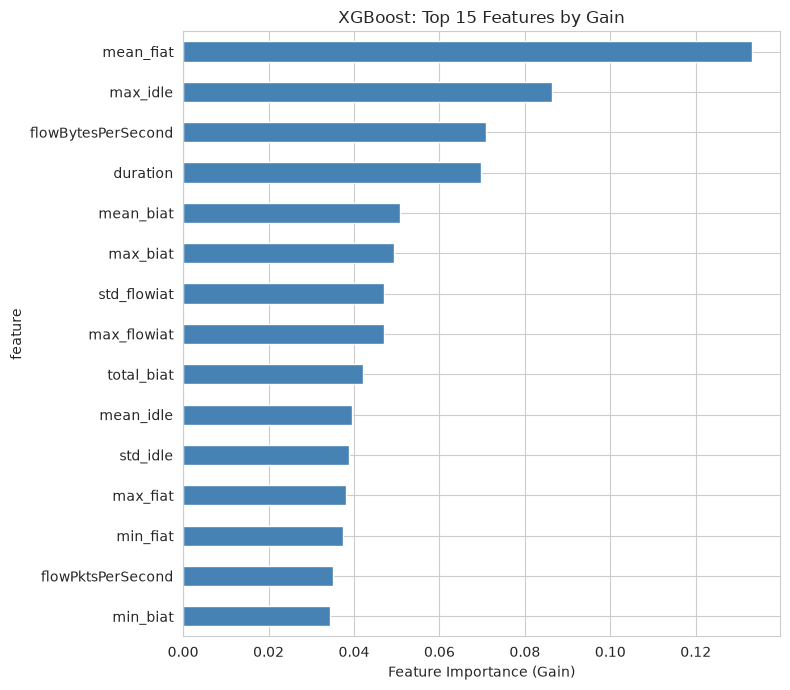

Top 5 features on the full data: ['mean_fiat', 'max_idle', 'flowBytesPerSecond', 'duration', 'mean_biat']


In [6]:
# Feature importance (gain) from a full-data XGBoost model for visualization
scaler_full = StandardScaler()
X_full_s = scaler_full.fit_transform(X)
sw_full = compute_sample_weight('balanced', y)
xgb_full = make_xgb()
xgb_full.fit(X_full_s, y, sample_weight=sw_full)

importances = xgb_full.feature_importances_
feat_imp = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': importances
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
feat_imp.tail(15).plot.barh(x='feature', y='importance', ax=ax,
                             color='steelblue', legend=False)
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title('XGBoost: Top 15 Features by Gain')
plt.tight_layout()
plt.show()

print('Top 5 features on the full data:', feat_imp.sort_values('importance', ascending=False)['feature'].tolist()[:5])

## 4. MLP Classifier

A multi-layer perceptron provides a neural network baseline. MLPClassifier does not
accept `sample_weight` in `fit()`, so the class-balanced gradient signal is delivered
instead by oversampling each training fold with `RandomOverSampler`.

In [7]:
def make_mlp():
    return MLPClassifier(
        hidden_layer_sizes=(256, 128, 64), activation='relu', solver='adam',
        alpha=1e-4, batch_size=256, learning_rate='adaptive',
        learning_rate_init=1e-3, max_iter=200, random_state=RANDOM_STATE,
        early_stopping=True, validation_fraction=0.1, n_iter_no_change=20
    )

# MLPClassifier does not expose sample_weight; the equivalent class-balanced gradient signal is delivered through RandomOverSampler on each training fold.
mlp_results = train_evaluate_cv(make_mlp, X, y, n_splits=5,
                                use_random_oversampler=True)
print_cv_summary(mlp_results, 'MLP (5-fold CV, class-balanced oversampling)')

=== MLP (5-fold CV, class-balanced oversampling) ===
Per-fold accuracy: ['0.8713', '0.8599', '0.8679', '0.8695', '0.8673']
Mean accuracy:     0.8672 +/- 0.0039

Per-class recall (from averaged CM):
  Browsing       : 84.5%
  Chat           : 73.3%
  FileTransfer   : 81.6%
  Streaming      : 83.7%
  VoIP           : 98.0%

              precision    recall  f1-score   support

    Browsing     0.8833    0.8448    0.8636      5000
        Chat     0.6641    0.7325    0.6966      2086
FileTransfer     0.8134    0.8156    0.8145      2950
   Streaming     0.7717    0.8370    0.8030       957
        VoIP     0.9966    0.9798    0.9881      5097

    accuracy                         0.8672     16090
   macro avg     0.8258    0.8419    0.8332     16090
weighted avg     0.8713    0.8672    0.8688     16090



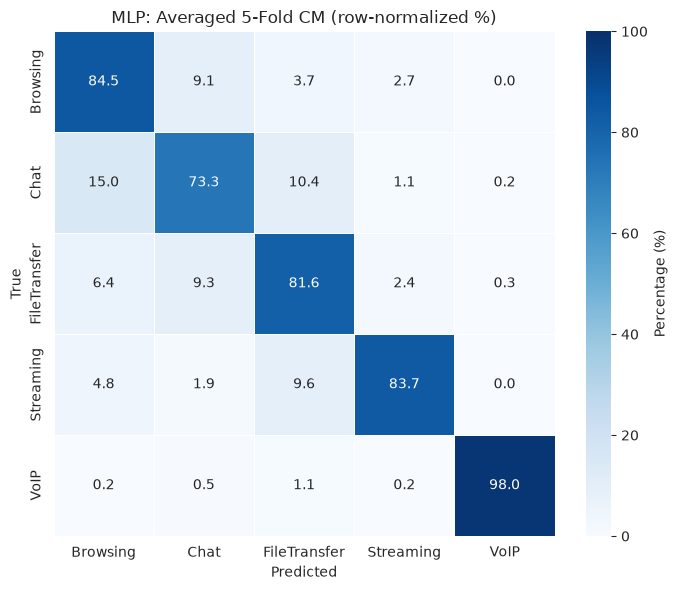

In [8]:
# MLP confusion matrix heatmap
fig, ax = plt.subplots(figsize=(7, 6))
plot_cm_heatmap(mlp_results['cm_avg_norm'], 'MLP: Averaged 5-Fold CM (row-normalized %)', ax=ax)
plt.tight_layout()
plt.show()

## 5. Comparison: XGBoost vs MLP

Side-by-side confusion matrices and per-class recall comparison to identify where
the two classifiers differ in their error profiles. These differences matter for the
analytical framework because different confusion matrix structures produce different
distorted load vectors through the composition.

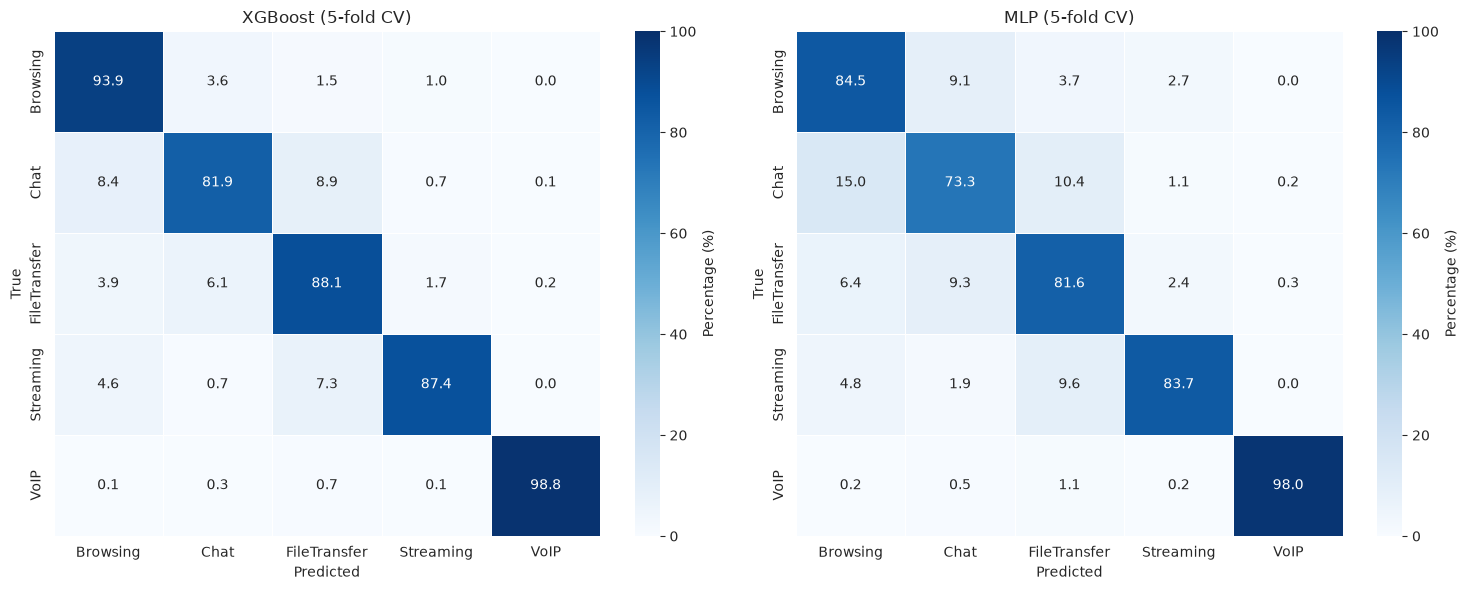

In [9]:
# Side-by-side CM heatmaps
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
plot_cm_heatmap(xgb_results['cm_avg_norm'], 'XGBoost (5-fold CV)', ax=axes[0])
plot_cm_heatmap(mlp_results['cm_avg_norm'], 'MLP (5-fold CV)', ax=axes[1])
plt.tight_layout()
plt.show()

In [10]:
# Per-class recall comparison table
comparison = pd.DataFrame({
    'Class': CLASS_ORDER,
    'XGBoost Recall': [xgb_results['cm_avg_norm'][i, i] for i in range(N_CLASSES)],
    'MLP Recall': [mlp_results['cm_avg_norm'][i, i] for i in range(N_CLASSES)],
})
comparison['Difference'] = comparison['XGBoost Recall'] - comparison['MLP Recall']
comparison = comparison.set_index('Class')

# Format as percentages
print('Per-class recall comparison:')
print(comparison.map(lambda x: f'{x:.2%}').to_string())
print()

# Overall accuracy comparison
xgb_acc = np.mean(xgb_results['accuracies'])
mlp_acc = np.mean(mlp_results['accuracies'])
print(f'Overall accuracy:')
print(f'  XGBoost: {xgb_acc:.4f} +/- {np.std(xgb_results["accuracies"]):.4f}')
print(f'  MLP:     {mlp_acc:.4f} +/- {np.std(mlp_results["accuracies"]):.4f}')
print(f'  Delta:   {xgb_acc - mlp_acc:+.4f}')

Per-class recall comparison:
             XGBoost Recall MLP Recall Difference
Class                                            
Browsing             93.88%     84.48%      9.40%
Chat                 81.88%     73.25%      8.63%
FileTransfer         88.07%     81.56%      6.51%
Streaming            87.36%     83.70%      3.66%
VoIP                 98.76%     97.98%      0.78%

Overall accuracy:
  XGBoost: 0.9242 +/- 0.0037
  MLP:     0.8672 +/- 0.0039
  Delta:   +0.0570


## 6. Degraded Condition 1: Distribution Shift (VPN Domain)

Models trained on non-VPN data (Scenario B) are tested on VPN data (Scenario A2).
VPN encryption alters flow-level statistical features (packet sizes, inter-arrival times),
causing a domain shift that degrades classification accuracy. This simulates a realistic
deployment scenario where a classifier trained on one network segment encounters
traffic from a different encryption domain.

In [11]:
# Load VPN ARFF data
# The VPN ARFF file has trailing commas on header lines (Excel artifact), so we parse it manually: skip to @DATA, then read as CSV with known columns.
vpn_path = str(VPN_ARFF)

# Find the @DATA line and read everything after it
with open(vpn_path, 'r') as f:
    lines = f.readlines()

data_start = None
for i, line in enumerate(lines):
    if line.strip().startswith('@DATA'):
        data_start = i + 1
        break

assert data_start is not None, 'Could not find @DATA marker in VPN ARFF'

# Parse data lines as CSV
from io import StringIO
data_text = ''.join(lines[data_start:])
col_names = FEATURE_COLS + ['class1']
df_vpn_raw = pd.read_csv(StringIO(data_text), header=None, names=col_names)

# Drop empty trailing rows (the ARFF file has a trailing newline)
df_vpn_raw = df_vpn_raw.dropna(subset=['class1']).reset_index(drop=True)

print(f'VPN ARFF loaded: {len(df_vpn_raw)} rows')
print(f'Raw VPN class distribution:')
print(df_vpn_raw['class1'].value_counts().to_string())

VPN ARFF loaded: 9793 rows
Raw VPN class distribution:
class1
VPN-BROWSING     2500
VPN-VOIP         2271
VPN-FT           1932
VPN-CHAT         1196
VPN-P2P           928
VPN-MAIL          491
VPN-STREAMING     475


In [12]:
# Filter to 5 thesis classes and relabel
VPN_LABEL_MAP = {
    'VPN-VOIP': 'VoIP',
    'VPN-CHAT': 'Chat',
    'VPN-BROWSING': 'Browsing',
    'VPN-FT': 'FileTransfer',
    'VPN-STREAMING': 'Streaming',
}
VPN_KEEP = list(VPN_LABEL_MAP.keys())

df_vpn = df_vpn_raw[df_vpn_raw['class1'].isin(VPN_KEEP)].copy()
df_vpn['class1'] = df_vpn['class1'].map(VPN_LABEL_MAP)

dropped_vpn = len(df_vpn_raw) - len(df_vpn)
print(f'VPN 5-class: {len(df_vpn)} flows (dropped {dropped_vpn} MAIL/P2P)')

# Apply same preprocessing as notebook 01
# Replace -1 sentinels with 0 and clip all negative values to 0.
# The VPN ARFF contains negative sentinels beyond -1 (e.g., -9 in min_flowiat) for unidirectional or degenerate flows.
for col in FEATURE_COLS:
    df_vpn[col] = df_vpn[col].replace(-1, 0)
    df_vpn[col] = df_vpn[col].clip(lower=0)

# Clip at 99.9th percentile (using VPN data's own percentiles)
for col in FEATURE_COLS:
    p999 = df_vpn[col].quantile(0.999)
    df_vpn[col] = df_vpn[col].clip(upper=p999)

# Prepare features and labels
X_vpn = df_vpn[FEATURE_COLS].values.astype(np.float64)
y_vpn = le.transform(df_vpn['class1'].values)

print(f'VPN test set shape: X={X_vpn.shape}')
print()
vpn_dist = df_vpn['class1'].value_counts().reindex(CLASS_ORDER)
print('VPN 5-class distribution:')
for cls in CLASS_ORDER:
    print(f'  {cls:15s}: {vpn_dist[cls]:5d}')
print(f'  {"Total":15s}: {vpn_dist.sum():5d}')

VPN 5-class: 8374 flows (dropped 1419 MAIL/P2P)
VPN test set shape: X=(8374, 23)

VPN 5-class distribution:
  Browsing       :  2500
  Chat           :  1196
  FileTransfer   :  1932
  Streaming      :   475
  VoIP           :  2271
  Total          :  8374


In [13]:
# Train on full non-VPN data, test on VPN data
# Fit scaler on non-VPN training data
scaler_vpn = StandardScaler()
X_train_vpn = scaler_vpn.fit_transform(X)
X_test_vpn = scaler_vpn.transform(X_vpn)

# XGBoost: train on non-VPN, test on VPN
xgb_vpn = make_xgb()
sw_train = compute_sample_weight('balanced', y)
xgb_vpn.fit(X_train_vpn, y, sample_weight=sw_train)
y_pred_xgb_vpn = xgb_vpn.predict(X_test_vpn)

cm_xgb_vpn_raw = confusion_matrix(y_vpn, y_pred_xgb_vpn, labels=np.arange(N_CLASSES))
cm_xgb_vpn = normalize_cm(cm_xgb_vpn_raw)
acc_xgb_vpn = accuracy_score(y_vpn, y_pred_xgb_vpn)

# MLP: train on non-VPN with RandomOverSampler, test on VPN
ros_vpn = RandomOverSampler(random_state=RANDOM_STATE)
X_train_vpn_bal, y_train_vpn_bal = ros_vpn.fit_resample(X_train_vpn, y)
mlp_vpn = make_mlp()
mlp_vpn.fit(X_train_vpn_bal, y_train_vpn_bal)
y_pred_mlp_vpn = mlp_vpn.predict(X_test_vpn)

cm_mlp_vpn_raw = confusion_matrix(y_vpn, y_pred_mlp_vpn, labels=np.arange(N_CLASSES))
cm_mlp_vpn = normalize_cm(cm_mlp_vpn_raw)
acc_mlp_vpn = accuracy_score(y_vpn, y_pred_mlp_vpn)

# Accuracy comparison
xgb_clean_acc = np.mean(xgb_results['accuracies'])
mlp_clean_acc = np.mean(mlp_results['accuracies'])

print('=== VPN Domain Shift Results ===')
print(f'XGBoost: clean={xgb_clean_acc:.4f}, VPN={acc_xgb_vpn:.4f}, '
      f'drop={xgb_clean_acc - acc_xgb_vpn:+.4f}')
print(f'MLP:     clean={mlp_clean_acc:.4f}, VPN={acc_mlp_vpn:.4f}, '
      f'drop={mlp_clean_acc - acc_mlp_vpn:+.4f}')
print()

# Per-class recall comparison
print('Per-class recall on VPN data:')
for i, cls in enumerate(CLASS_ORDER):
    print(f'  {cls:15s}: XGBoost={cm_xgb_vpn[i,i]:.1%}, MLP={cm_mlp_vpn[i,i]:.1%}')

=== VPN Domain Shift Results ===
XGBoost: clean=0.9242, VPN=0.7941, drop=+0.1301
MLP:     clean=0.8672, VPN=0.3203, drop=+0.5469

Per-class recall on VPN data:
  Browsing       : XGBoost=96.5%, MLP=11.7%
  Chat           : XGBoost=19.8%, MLP=13.7%
  FileTransfer   : XGBoost=87.2%, MLP=34.5%
  Streaming      : XGBoost=25.7%, MLP=20.4%
  VoIP           : XGBoost=96.6%, MLP=64.4%


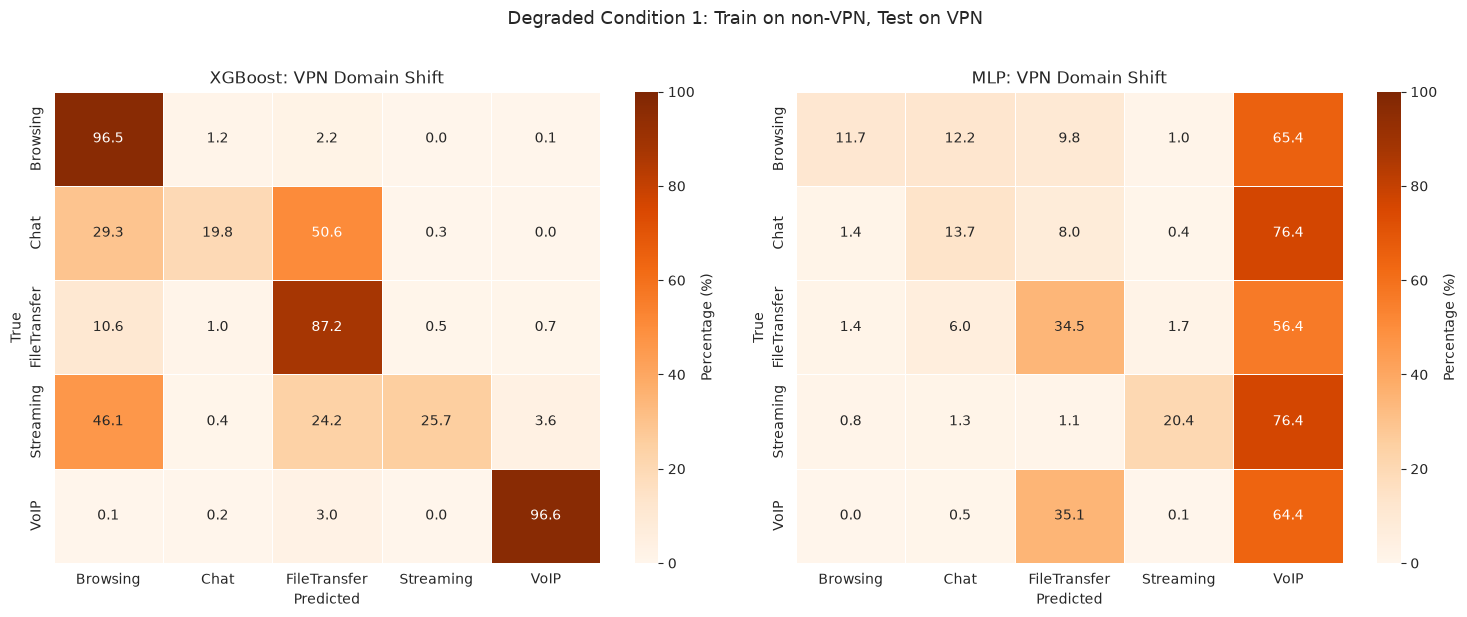

In [14]:
# VPN domain shift CM heatmaps
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
plot_cm_heatmap(cm_xgb_vpn, 'XGBoost: VPN Domain Shift', ax=axes[0], cmap='Oranges')
plot_cm_heatmap(cm_mlp_vpn, 'MLP: VPN Domain Shift', ax=axes[1], cmap='Oranges')
plt.suptitle('Degraded Condition 1: Train on non-VPN, Test on VPN', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Degraded Condition 2: Reduced Features

Removing the five most important features (by XGBoost gain) simulates a scenario
where key discriminative features are unavailable, for example under encryption,
protocol changes or privacy constraints. The ranking is refit inside every
cross-validation fold on its training partition only, so the held-out fold never
influences which features are removed. This is the protocol behind the
`xgb_reduced_feat` and `mlp_reduced_feat` slots of the distributed archive
(`scripts/iscx/iscx_reduced_feature_ranking.py`).

In [15]:
# Reduced features with the ranking refit inside each fold
def train_evaluate_cv_reduced(model_fn, X, y, n_splits=5, n_drop=5,
                              use_sample_weight=False, use_random_oversampler=False):
    """Per-fold variant of train_evaluate_cv: rank features by XGBoost gain on the training partition of each fold, drop the top n_drop, then train model_fn on the remaining features. Returns the same dict as train_evaluate_cv plus the features dropped in every fold."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    cms_raw, accuracies, reports, y_true_all, y_pred_all, dropped = [], [], [], [], [], []
    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Ranking on the training fold only
        ranker = make_xgb()
        ranker.fit(StandardScaler().fit_transform(X_train), y_train,
                   sample_weight=compute_sample_weight('balanced', y_train))
        top = np.argsort(ranker.feature_importances_)[::-1][:n_drop]
        keep = [i for i in range(X.shape[1]) if i not in set(top)]
        dropped.append([FEATURE_COLS[i] for i in top])

        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train[:, keep])
        X_test_s = scaler.transform(X_test[:, keep])
        if use_random_oversampler:
            ros = RandomOverSampler(random_state=RANDOM_STATE + fold_idx)
            X_train_fit, y_train_fit = ros.fit_resample(X_train_s, y_train)
        else:
            X_train_fit, y_train_fit = X_train_s, y_train

        model = model_fn()
        if use_sample_weight:
            model.fit(X_train_fit, y_train_fit,
                      sample_weight=compute_sample_weight('balanced', y_train_fit))
        else:
            model.fit(X_train_fit, y_train_fit)
        y_pred = model.predict(X_test_s)

        cms_raw.append(confusion_matrix(y_test, y_pred, labels=np.arange(N_CLASSES)))
        accuracies.append(accuracy_score(y_test, y_pred))
        reports.append(classification_report(y_test, y_pred, output_dict=True, zero_division=0))
        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

    cm_avg_raw = np.mean(cms_raw, axis=0)
    return {
        'cms_raw': cms_raw,
        'cm_avg_raw': cm_avg_raw,
        'cm_avg_norm': normalize_cm(cm_avg_raw),
        'accuracies': accuracies,
        'reports': reports,
        'y_true_all': np.array(y_true_all),
        'y_pred_all': np.array(y_pred_all),
        'dropped_per_fold': dropped,
    }

xgb_reduced = train_evaluate_cv_reduced(make_xgb, X, y, n_splits=5, use_sample_weight=True)
for k, feats in enumerate(xgb_reduced['dropped_per_fold']):
    print(f'fold {k}: removed {feats}')
print()
print_cv_summary(xgb_reduced, 'XGBoost (reduced features, per-fold ranking, 5-fold CV)')


fold 0: removed ['mean_fiat', 'flowBytesPerSecond', 'duration', 'max_idle', 'max_biat']
fold 1: removed ['mean_fiat', 'duration', 'flowBytesPerSecond', 'max_idle', 'mean_biat']
fold 2: removed ['mean_fiat', 'flowBytesPerSecond', 'duration', 'mean_biat', 'max_biat']
fold 3: removed ['mean_fiat', 'max_idle', 'flowBytesPerSecond', 'duration', 'max_biat']
fold 4: removed ['mean_fiat', 'flowBytesPerSecond', 'duration', 'max_flowiat', 'max_biat']

=== XGBoost (reduced features, per-fold ranking, 5-fold CV) ===
Per-fold accuracy: ['0.9040', '0.8990', '0.9046', '0.9021', '0.8987']
Mean accuracy:     0.9017 +/- 0.0025

Per-class recall (from averaged CM):
  Browsing       : 89.5%
  Chat           : 79.8%
  FileTransfer   : 85.6%
  Streaming      : 85.9%
  VoIP           : 98.5%

              precision    recall  f1-score   support

    Browsing     0.9182    0.8954    0.9066      5000
        Chat     0.7466    0.7982    0.7715      2086
FileTransfer     0.8445    0.8559    0.8502      2950
  

In [16]:
# MLP with reduced features (per-fold ranking, class-balanced oversampling on each training fold)
mlp_reduced = train_evaluate_cv_reduced(make_mlp, X, y, n_splits=5, use_random_oversampler=True)
print_cv_summary(mlp_reduced, 'MLP (reduced features, per-fold ranking, 5-fold CV, class-balanced oversampling)')


=== MLP (reduced features, per-fold ranking, 5-fold CV, class-balanced oversampling) ===
Per-fold accuracy: ['0.8272', '0.8316', '0.8297', '0.8393', '0.8061']
Mean accuracy:     0.8268 +/- 0.0111

Per-class recall (from averaged CM):
  Browsing       : 76.9%
  Chat           : 72.8%
  FileTransfer   : 75.1%
  Streaming      : 80.9%
  VoIP           : 97.2%

              precision    recall  f1-score   support

    Browsing     0.8756    0.7688    0.8187      5000
        Chat     0.6394    0.7277    0.6807      2086
FileTransfer     0.7620    0.7508    0.7564      2950
   Streaming     0.6192    0.8088    0.7014       957
        VoIP     0.9580    0.9716    0.9647      5097

    accuracy                         0.8268     16090
   macro avg     0.7708    0.8055    0.7844     16090
weighted avg     0.8350    0.8268    0.8287     16090



=== Recall Impact of Feature Removal ===
Class              XGB Full   XGB Reduced     Delta    MLP Full   MLP Reduced     Delta
Browsing              93.9%         89.5%     -4.3%       84.5%         76.9%     -7.6%
Chat                  81.9%         79.8%     -2.1%       73.3%         72.8%     -0.5%
FileTransfer          88.1%         85.6%     -2.5%       81.6%         75.1%     -6.5%
Streaming             87.4%         85.9%     -1.5%       83.7%         80.9%     -2.8%
VoIP                  98.8%         98.5%     -0.3%       98.0%         97.2%     -0.8%


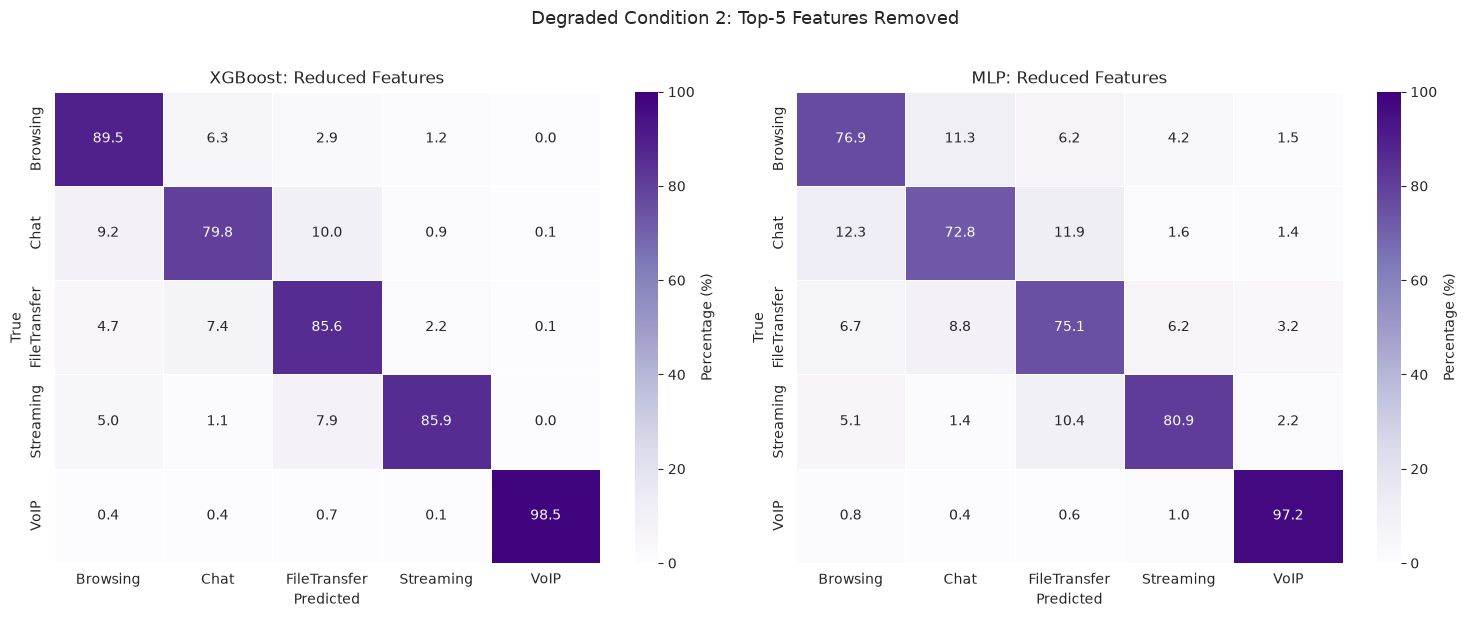

In [17]:
# Recall comparison: full features vs reduced features
print('=== Recall Impact of Feature Removal ===')
print(f'{"Class":15s}  {"XGB Full":>10s}  {"XGB Reduced":>12s}  {"Delta":>8s}  '
      f'{"MLP Full":>10s}  {"MLP Reduced":>12s}  {"Delta":>8s}')
print('=' * 85)
for i, cls in enumerate(CLASS_ORDER):
    xgb_full_r = xgb_results['cm_avg_norm'][i, i]
    xgb_red_r = xgb_reduced['cm_avg_norm'][i, i]
    mlp_full_r = mlp_results['cm_avg_norm'][i, i]
    mlp_red_r = mlp_reduced['cm_avg_norm'][i, i]
    print(f'{cls:15s}  {xgb_full_r:10.1%}  {xgb_red_r:12.1%}  {xgb_red_r-xgb_full_r:+8.1%}  '
          f'{mlp_full_r:10.1%}  {mlp_red_r:12.1%}  {mlp_red_r-mlp_full_r:+8.1%}')

# Side-by-side CM heatmaps for reduced features
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
plot_cm_heatmap(xgb_reduced['cm_avg_norm'], 'XGBoost: Reduced Features', ax=axes[0], cmap='Purples')
plot_cm_heatmap(mlp_reduced['cm_avg_norm'], 'MLP: Reduced Features', ax=axes[1], cmap='Purples')
plt.suptitle('Degraded Condition 2: Top-5 Features Removed', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 8. Confusion Matrix Ensemble Summary

Compile all confusion matrices (published and own) into a single collection. The
FlowPic matrices are permuted from their published class order into the thesis
order; the mapping is documented in `src/analytical/published_cms.py`.

In [18]:
from src.analytical.published_cms import (
    FLOWPIC_CM_NONVPN, FLOWPIC_CM_VPN, FLOWPIC_CM_TOR,
    FLOWPIC_CLASSES_5
)

# The FlowPic and thesis class orders and the Video-to-Streaming remap are stated in src/analytical/published_cms.py.

# Build permutation index: for each thesis class, find its position in FlowPic order
FLOWPIC_TO_THESIS = {
    'VoIP': 'VoIP',
    'Video': 'Streaming',
    'File Transfer': 'FileTransfer',
    'Chat': 'Chat',
    'Browsing': 'Browsing',
}

# Permutation: thesis_class[i] comes from flowpic_class[perm[i]]
perm = []
for thesis_cls in CLASS_ORDER:
    # Find which FlowPic index maps to this thesis class
    for fp_idx, fp_cls in enumerate(FLOWPIC_CLASSES_5):
        if FLOWPIC_TO_THESIS[fp_cls] == thesis_cls:
            perm.append(fp_idx)
            break
perm = np.array(perm)

print(f'FlowPic order: {FLOWPIC_CLASSES_5}')
print(f'Thesis order:  {CLASS_ORDER}')
print(f'Permutation:   {perm}')
print(f'Verification:  {[FLOWPIC_CLASSES_5[i] for i in perm]} -> {CLASS_ORDER}')

def permute_cm(cm_flowpic, perm):
    """Permute a FlowPic CM to thesis class ordering."""
    return cm_flowpic[np.ix_(perm, perm)]

# Permute all three FlowPic CMs
fp_nonvpn = permute_cm(FLOWPIC_CM_NONVPN, perm)
fp_vpn = permute_cm(FLOWPIC_CM_VPN, perm)
fp_tor = permute_cm(FLOWPIC_CM_TOR, perm)

# Check the known diagonal values after permutation
expected_diag_nonvpn = [0.909, 0.278, 1.000, 0.986, 0.984]
actual_diag_nonvpn = np.diag(fp_nonvpn)
print('\nNon-VPN diagonal verification:')
for i, cls in enumerate(CLASS_ORDER):
    status = 'OK' if np.isclose(actual_diag_nonvpn[i], expected_diag_nonvpn[i], atol=1e-3) else 'MISMATCH'
    print(f'  {cls:15s}: expected={expected_diag_nonvpn[i]:.3f}, got={actual_diag_nonvpn[i]:.3f} [{status}]')

# Row sums check
for name, cm in [('NonVPN', fp_nonvpn), ('Tor', fp_tor)]:
    rs = cm.sum(axis=1)
    active = rs > 0
    assert np.allclose(rs[active], 1.0, atol=1e-3), f'{name} row sums not 1.0: {rs}'
print('\nAll permuted CMs pass row-sum validation.')

FlowPic order: ['VoIP', 'Video', 'File Transfer', 'Chat', 'Browsing']
Thesis order:  ['Browsing', 'Chat', 'FileTransfer', 'Streaming', 'VoIP']
Permutation:   [4 3 2 1 0]
Verification:  ['Browsing', 'Chat', 'File Transfer', 'Video', 'VoIP'] -> ['Browsing', 'Chat', 'FileTransfer', 'Streaming', 'VoIP']

Non-VPN diagonal verification:
  Browsing       : expected=0.909, got=0.909 [OK]
  Chat           : expected=0.278, got=0.278 [OK]
  FileTransfer   : expected=1.000, got=1.000 [OK]
  Streaming      : expected=0.986, got=0.986 [OK]
  VoIP           : expected=0.984, got=0.984 [OK]

All permuted CMs pass row-sum validation.


In [19]:
# Assemble all empirical confusion matrices
ALL_CMS = {
    # Tier 1: Published (permuted to thesis order)
    'flowpic_nonvpn': fp_nonvpn,
    'flowpic_vpn': fp_vpn,
    'flowpic_tor': fp_tor,
    # Tier 2: Own classifiers (already in thesis order)
    'xgb_clean': xgb_results['cm_avg_norm'],
    'mlp_clean': mlp_results['cm_avg_norm'],
    'xgb_vpn_shift': cm_xgb_vpn,
    'mlp_vpn_shift': cm_mlp_vpn,
    'xgb_reduced_feat': xgb_reduced['cm_avg_norm'],
    'mlp_reduced_feat': mlp_reduced['cm_avg_norm'],
}

# Summary table
summary_rows = []
for name, cm in ALL_CMS.items():
    row_sums = cm.sum(axis=1)
    active = row_sums > 0
    diag = np.diag(cm)
    active_diag = diag[active]
    # Overall accuracy (balanced, over active classes)
    bal_acc = np.mean(active_diag) if len(active_diag) > 0 else 0.0
    min_recall = np.min(active_diag) if len(active_diag) > 0 else 0.0
    # Max off-diagonal entry
    off_diag = cm.copy()
    np.fill_diagonal(off_diag, 0)
    max_offdiag = np.max(off_diag)
    
    tier = 'Published' if name.startswith('flowpic') else 'Own'
    summary_rows.append({
        'CM Name': name,
        'Source': tier,
        'Balanced Acc': f'{bal_acc:.1%}',
        'Min Recall': f'{min_recall:.1%}',
        'Max Off-Diag': f'{max_offdiag:.1%}',
    })

summary_df = pd.DataFrame(summary_rows)
print('=== Confusion Matrix Ensemble Summary ===')
print(f'Total CMs: {len(ALL_CMS)} (3 published + 6 own)')
print()
print(summary_df.to_string(index=False))

=== Confusion Matrix Ensemble Summary ===
Total CMs: 9 (3 published + 6 own)

         CM Name    Source Balanced Acc Min Recall Max Off-Diag
  flowpic_nonvpn Published        83.1%      27.8%        72.2%
     flowpic_vpn Published        98.3%      93.3%         6.7%
     flowpic_tor Published        70.6%       0.0%        70.8%
       xgb_clean       Own        90.0%      81.9%         8.9%
       mlp_clean       Own        84.2%      73.3%        15.0%
   xgb_vpn_shift       Own        65.2%      19.8%        50.6%
   mlp_vpn_shift       Own        28.9%      11.7%        76.4%
xgb_reduced_feat       Own        87.9%      79.8%        10.0%
mlp_reduced_feat       Own        80.6%      72.8%        12.3%


In [20]:
# Save all empirical CMs
import os
if os.environ.get('NB02_FORCE_OVERWRITE') != '1':
    raise RuntimeError('Set NB02_FORCE_OVERWRITE=1 to overwrite confusion_matrices.npz.')
# Keep the keys that other stages add to the archive (fold statistics, seed sweeps)
archive_path = PROCESSED_DIR / 'confusion_matrices.npz'
existing = dict(np.load(archive_path, allow_pickle=True)) if archive_path.exists() else {}
existing.update({'class_order': CLASS_ORDER, 't_k': T_K, **ALL_CMS})
np.savez(archive_path, **existing)

# Verify the save
loaded = np.load(PROCESSED_DIR / 'confusion_matrices.npz', allow_pickle=True)
print(f'Saved {len(ALL_CMS)} CMs to {PROCESSED_DIR / "confusion_matrices.npz"}')
print(f'Keys: {sorted([k for k in loaded.keys() if k not in ["class_order", "t_k"]])}')

Saved 9 CMs to ../data/processed/confusion_matrices.npz
Keys: ['best_r0.50', 'best_r0.51', 'best_r0.52', 'best_r0.53', 'best_r0.54', 'best_r0.55', 'best_r0.56', 'best_r0.57', 'best_r0.58', 'best_r0.59', 'best_r0.60', 'best_r0.61', 'best_r0.62', 'best_r0.63', 'best_r0.64', 'best_r0.65', 'best_r0.66', 'best_r0.67', 'best_r0.68', 'best_r0.69', 'best_r0.70', 'best_r0.71', 'best_r0.72', 'best_r0.73', 'best_r0.74', 'best_r0.75', 'best_r0.76', 'best_r0.77', 'best_r0.78', 'best_r0.79', 'best_r0.80', 'best_r0.81', 'best_r0.82', 'best_r0.83', 'best_r0.84', 'best_r0.85', 'best_r0.86', 'best_r0.87', 'best_r0.88', 'best_r0.89', 'best_r0.90', 'best_r0.91', 'best_r0.92', 'best_r0.93', 'best_r0.94', 'best_r0.95', 'best_r0.96', 'best_r0.97', 'best_r0.98', 'best_r0.99', 'flowpic_nonvpn', 'flowpic_tor', 'flowpic_vpn', 'mlp_clean', 'mlp_clean_unweighted', 'mlp_cv_acc_folds', 'mlp_cv_bal_folds', 'mlp_reduced_feat', 'mlp_vpn_shift', 'uniform_r0.50', 'uniform_r0.51', 'uniform_r0.52', 'uniform_r0.53', 'unifor

## 9. Synthetic Confusion Matrix Generator

Three parametric CM models that sweep recall from 0.5 to 0.99, enabling the analytical
framework to study how different error structures affect capacity dimensioning:

1. **Uniform spillover:** errors spread equally across all other classes
2. **Worst-case spillover:** all errors directed to the highest-demand class (Streaming, t=15)
3. **Best-case spillover:** all errors directed to the lowest-demand class (Chat or VoIP, t=1)

In [21]:
def uniform_spillover(K, recall):
    """Uniform spillover CM: C_kk = recall, C_kj = (1-recall)/(K-1) for j != k. All classes have identical error profiles."""
    cm = np.full((K, K), (1 - recall) / (K - 1))
    np.fill_diagonal(cm, recall)
    return cm

def worst_case_spillover(K, recall, t_k):
    """Worst-case spillover: all misclassification mass goes to the class with the highest bandwidth demand (Streaming, t=15). This maximizes the distortion of the offered load vector toward high-demand classes."""
    target = np.argmax(t_k)  # Streaming (index 3 in alphabetical order)
    cm = np.zeros((K, K))
    np.fill_diagonal(cm, recall)
    for i in range(K):
        if i == target:
            # Target class errors go uniformly to others
            for j in range(K):
                if j != i:
                    cm[i, j] = (1 - recall) / (K - 1)
        else:
            cm[i, target] = 1 - recall
    return cm

def best_case_spillover(K, recall, t_k):
    """Best-case spillover: all misclassification mass goes to the class with the lowest bandwidth demand (VoIP or Chat, t=1). This minimizes the load distortion because errors shift traffic to low-demand classes."""
    # Among classes with minimum t_k, pick the last one (VoIP, index 4)
    min_t = np.min(t_k)
    candidates = np.where(t_k == min_t)[0]
    target = candidates[-1]  # VoIP (index 4 in alphabetical order)
    cm = np.zeros((K, K))
    np.fill_diagonal(cm, recall)
    for i in range(K):
        if i == target:
            # Target class errors go uniformly to others
            for j in range(K):
                if j != i:
                    cm[i, j] = (1 - recall) / (K - 1)
        else:
            cm[i, target] = 1 - recall
    return cm

# Generate sweep: recall from 0.50 to 0.99
recall_values = np.arange(0.50, 1.00, 0.01)
synthetic_cms = {}

for r in recall_values:
    r_key = f'{r:.2f}'
    synthetic_cms[f'uniform_r{r_key}'] = uniform_spillover(N_CLASSES, r)
    synthetic_cms[f'worst_r{r_key}'] = worst_case_spillover(N_CLASSES, r, T_K)
    synthetic_cms[f'best_r{r_key}'] = best_case_spillover(N_CLASSES, r, T_K)

print(f'Generated {len(synthetic_cms)} synthetic CMs '
      f'(3 types x {len(recall_values)} recall values)')

# Verify row-stochasticity for a sample
for name in ['uniform_r0.80', 'worst_r0.80', 'best_r0.80']:
    cm = synthetic_cms[name]
    assert np.allclose(cm.sum(axis=1), 1.0), f'{name} not row-stochastic'
    assert np.all(cm >= 0), f'{name} has negative entries'
print('All sample CMs pass validation.')

Generated 150 synthetic CMs (3 types x 50 recall values)
All sample CMs pass validation.


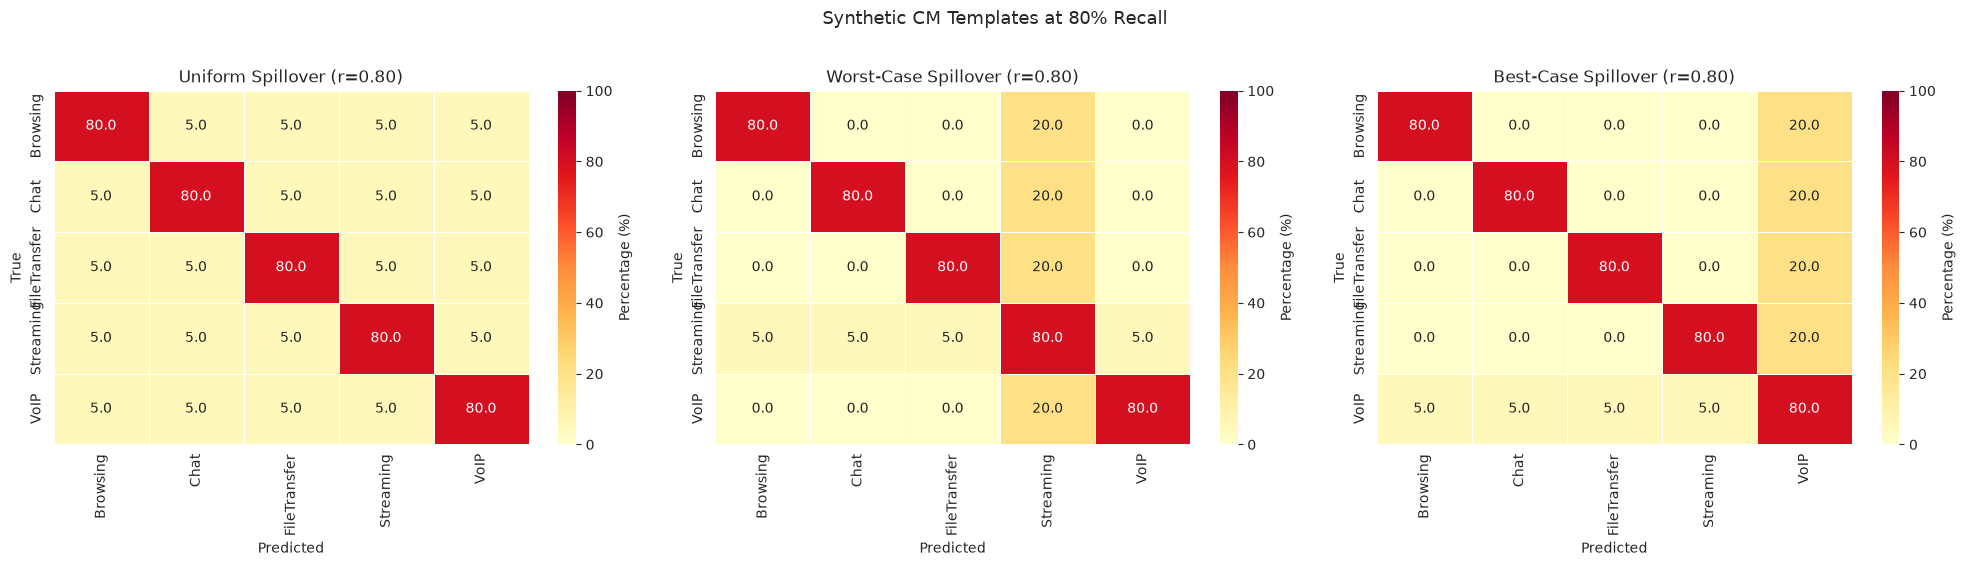

In [22]:
# Visualize example CMs at recall = 0.80
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

example_cms = [
    (synthetic_cms['uniform_r0.80'], 'Uniform Spillover (r=0.80)'),
    (synthetic_cms['worst_r0.80'], 'Worst-Case Spillover (r=0.80)'),
    (synthetic_cms['best_r0.80'], 'Best-Case Spillover (r=0.80)'),
]

for ax, (cm, title) in zip(axes, example_cms):
    plot_cm_heatmap(cm, title, ax=ax, cmap='YlOrRd')

plt.suptitle('Synthetic CM Templates at 80% Recall', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [23]:
import os
if os.environ.get('NB02_FORCE_OVERWRITE') != '1':
    raise RuntimeError('Set NB02_FORCE_OVERWRITE=1 to overwrite confusion_matrices.npz.')
# Save the synthetic CMs alongside the empirical ones
save_dict = dict(ALL_CMS)
save_dict['class_order'] = CLASS_ORDER
save_dict['t_k'] = T_K
save_dict.update(synthetic_cms)

archive_path = PROCESSED_DIR / 'confusion_matrices.npz'
existing = dict(np.load(archive_path, allow_pickle=True)) if archive_path.exists() else {}
existing.update(save_dict)
np.savez(archive_path, **existing)

print(f'Updated confusion_matrices.npz with {len(synthetic_cms)} synthetic CMs')
print(f'Total arrays in file: {len(save_dict)}')

Updated confusion_matrices.npz with 150 synthetic CMs
Total arrays in file: 161


## 10. Composition Preview

How each empirical CM distorts the offered-load vector and shifts the blocking
probabilities in the OTT/IPTV scenario, ahead of the full analysis in notebook 03.

In [24]:
from src.analytical.kaufman_roberts import kaufman_roberts, bridge_equation, blocking_deviation, capacity_overhead

# OTT/IPTV scenario parameters (alphabetical class order)
V = 150       # Capacity in AUs
a = np.array([25.0, 15.0, 20.0, 8.0, 20.0])  # Erlangs: Browsing, Chat, FT, Streaming, VoIP
t = np.array([2, 1, 8, 15, 1])                # AUs: Browsing, Chat, FT, Streaming, VoIP

# Baseline blocking (perfect classifier)
_, B_true = kaufman_roberts(V, a, t)
B_target = max(B_true.max(), 0.01)

print('=== OTT/IPTV Scenario Parameters ===')
print(f'Capacity V = {V} AUs')
print(f'Classes:  {CLASS_ORDER}')
print(f'Loads a:  {a} Erlangs')
print(f'Demands t: {t} AUs')
print(f'Total offered load: {np.sum(a * t)} AU·Erl')
print()
print('Baseline blocking (perfect classifier):')
for i, cls in enumerate(CLASS_ORDER):
    print(f'  B_{cls:15s} = {B_true[i]:.6f}')
print(f'  B_target = {B_target:.4f}')

=== OTT/IPTV Scenario Parameters ===
Capacity V = 150 AUs
Classes:  ['Browsing', 'Chat', 'FileTransfer', 'Streaming', 'VoIP']
Loads a:  [25. 15. 20.  8. 20.] Erlangs
Demands t: [ 2  1  8 15  1] AUs
Total offered load: 365.0 AU·Erl

Baseline blocking (perfect classifier):
  B_Browsing        = 0.222270
  B_Chat            = 0.117620
  B_FileTransfer    = 0.644022
  B_Streaming       = 0.864618
  B_VoIP            = 0.117620
  B_target = 0.8646


In [25]:
# Compute composition impact for each empirical CM
bridge_results = {}
print(f'{"CM Name":25s}  {"Delta_B max":>12s}  {"Capacity Overhead":>18s}')
print('=' * 60)

for name, cm in ALL_CMS.items():
    # Handle CMs with zero rows (e.g., FlowPic VPN has no Browsing samples). Replace zero rows with identity (no error for absent classes) so the composition's row-stochastic assertion passes.
    cm_fixed = cm.copy()
    row_sums = cm_fixed.sum(axis=1)
    for i in range(N_CLASSES):
        if row_sums[i] < 1e-9:
            cm_fixed[i, i] = 1.0  # assume perfect classification for absent class
    
    result = blocking_deviation(V, a, cm_fixed, t)
    
    # Capacity overhead: find V' such that B_k(a_hat, V') <= B_target
    a_hat = bridge_equation(cm_fixed, a)
    try:
        V_prime = capacity_overhead(a_hat, t, B_target, V)
        overhead_pct = (V_prime - V) / V * 100
        overhead_str = f'{overhead_pct:+.1f}% (V\'={V_prime})'
    except ValueError:
        V_prime = None
        overhead_str = 'exceeds search range'
    
    bridge_results[name] = {
        'a_hat': a_hat,
        'B_true': result['B_true'],
        'B_dist': result['B_distorted'],
        'delta_B': result['delta_B'],
        'V_prime': V_prime,
    }
    
    delta_max = np.max(np.abs(result['delta_B']))
    print(f'{name:25s}  {delta_max:12.6f}  {overhead_str:>18s}')

CM Name                     Delta_B max   Capacity Overhead
flowpic_nonvpn                 0.020405      +4.7% (V'=157)
flowpic_vpn                    0.009010      +0.0% (V'=150)
flowpic_tor                    0.238731      +0.0% (V'=150)
xgb_clean                      0.001260      +0.7% (V'=151)
mlp_clean                      0.000984      +0.0% (V'=150)
xgb_vpn_shift                  0.050066     +10.7% (V'=166)
mlp_vpn_shift                  0.121555      +0.0% (V'=150)
xgb_reduced_feat               0.000175      +0.7% (V'=151)
mlp_reduced_feat               0.004147      +0.0% (V'=150)


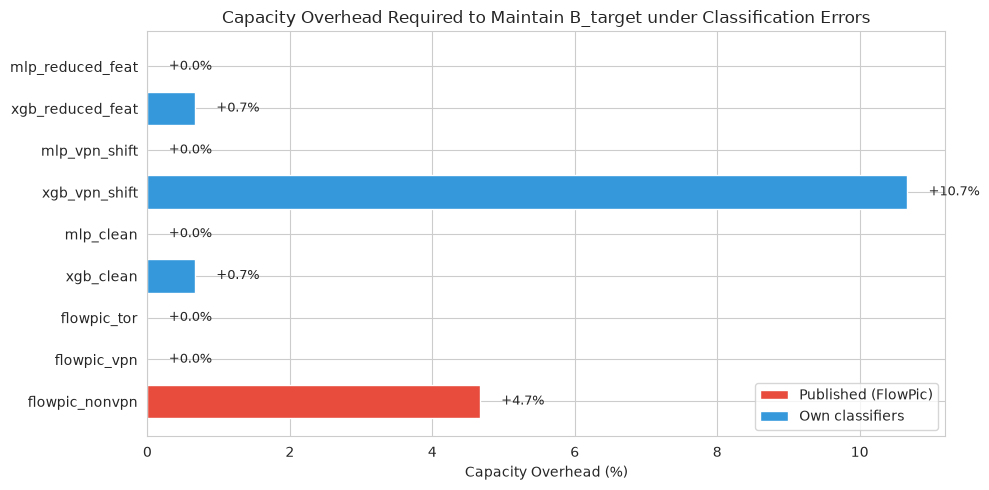

In [26]:
# Bar chart: capacity overhead for each CM
cm_names = list(bridge_results.keys())
overheads = []
for name in cm_names:
    vp = bridge_results[name]['V_prime']
    if vp is not None:
        overheads.append((vp - V) / V * 100)
    else:
        overheads.append(0)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if name.startswith('flowpic') else '#3498db' for name in cm_names]
bars = ax.barh(cm_names, overheads, color=colors, edgecolor='white')
ax.set_xlabel('Capacity Overhead (%)')
ax.set_title('Capacity Overhead Required to Maintain B_target under Classification Errors')
ax.axvline(x=0, color='black', linewidth=0.5)

# Add value labels
for bar, val in zip(bars, overheads):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:+.1f}%', va='center', fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Published (FlowPic)'),
                   Patch(facecolor='#3498db', label='Own classifiers')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

**Summary of outputs produced:**

- 9 empirical confusion matrices (3 published FlowPic + 6 own classifiers)
- 150 synthetic confusion matrices (3 types x 50 recall values)
- All saved to `data/processed/confusion_matrices.npz`

**Next step:** `03_blocking_deviation.ipynb` uses these CMs as input to the
Kaufman-Roberts analysis: blocking deviations, sensitivity surfaces and capacity
overhead across the scenarios.